<a href="https://colab.research.google.com/github/awaiskhan131931-ctrl/codealpa_Disease-Prediction-from-Medical-Data/blob/main/codealpa_Disease_Prediction_from_Medical_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.


This cell downloads the 'breast-cancer-wisconsin-data' dataset from KaggleHub and stores its path.

In [ ]:
import pandas as pd
df = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')

df = df.drop(['Unnamed: 32','id'],axis = 1)

df['diagnosis'] = df['diagnosis'].map({'M':1,'B':0})

x = df.drop(['diagnosis'],axis = 1)
y = df['diagnosis']

This cell loads the dataset into a pandas DataFrame, drops unnecessary columns ('Unnamed: 32' and 'id'), converts the 'diagnosis' column from categorical ('M', 'B') to numerical (1, 0), and then separates the features (x) from the target variable (y).

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

This cell uses `StandardScaler` from `sklearn.preprocessing` to standardize the feature data `x`. Standardization is a common preprocessing step to scale features to have zero mean and unit variance, which can improve the performance of many machine learning models.

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 ,random_state=42)

This cell splits the preprocessed data into training and testing sets using `train_test_split` from `sklearn.model_selection`. 80% of the data is used for training (`x_train`, `y_train`) and 20% for testing (`x_test`, `y_test`), with `random_state=42` ensuring reproducibility.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
print(f'the training result = {model.score(x_train,y_train)*100}%\n the testing score  : {model.score(x_test,y_test)*100}%')

the training result = 98.68131868131869%
 the testing score  : 97.36842105263158%


This cell initializes and trains a `LogisticRegression` model on the training data (`x_train`, `y_train`). After training, it prints the model's accuracy on both the training and testing sets, indicating how well the model learned and generalizes to unseen data.

**bold text**

This cell calculates and visualizes the confusion matrix for the model's predictions on the test set. The confusion matrix helps in understanding the performance of a classification model, showing true positives, true negatives, false positives, and false negatives.

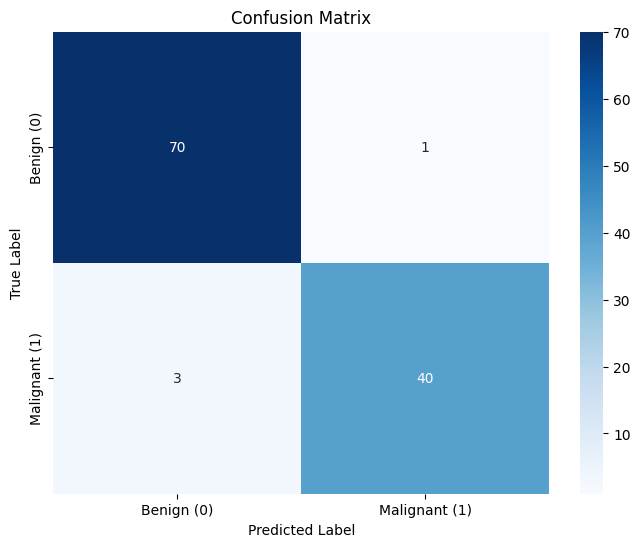

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = model.predict(x_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

This cell saves the trained `LogisticRegression` model and the `StandardScaler` object to disk using `joblib`. This allows for later reuse of the trained model and scaler without needing to retrain or refit them.

In [ ]:
import joblib
joblib.dump(model,'model.pkl')
joblib.dump(scaler,'scaler.pkl')
print('model are save')

model are save


This cell loads the previously saved model and scaler from their respective `.pkl` files using `joblib`. This step is crucial for deploying the model or using it for new predictions without retraining.

In [ ]:
called_model = joblib.load('model.pkl')
call_scaler = joblib.load('scaler.pkl')
print('load success fully')

load success fully


This cell creates a new pandas DataFrame containing a single row of sample data. This data represents a new, unseen patient's breast cancer features, which will be used to make a prediction.

In [ ]:
new = pd.DataFrame([[17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,0.24,34,34,234,24,3,343,242,3434,2,34234,234,234,23,43,434,3,43,434,0,454,5]])

This cell first loads the saved model and scaler. Then, it uses the loaded scaler to transform the new sample data (ensuring it's scaled consistently with the training data). Finally, it uses the loaded model to predict the diagnosis (Malignant or Benign) for the new data and prints the result.

In [ ]:
import joblib
called_model = joblib.load('model.pkl')
call_scaler = joblib.load('scaler.pkl')

new = call_scaler.transform(new)
prediction = called_model.predict(new)

if prediction == 1:
  print('Maliganant')
else:
  print('benign')

Maliganant


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
